# Portada de Entrega
Universidad del Valle de Guatemala
Inteligencia Artificial - Laboratorio 02
Javier España
Ángel Esquit
Roberto Barreda

Repositorio: https://github.com/Javier-Espana/Lab02-IA.git

# Laboratorio 2 - Inciso 4

In [9]:
import re
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, classification_report, confusion_matrix, roc_curve
)

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

In [10]:
#carga data
df = pd.read_csv(Path('spam_ham_es_dataset_v1.csv'))
df = df.dropna(subset=['tipo', 'texto']).copy()
df['texto'] = df['texto'].astype(str).str.strip()
df = df[df['texto'] != ''].copy()

label_map = {'ham': 0, 'spam': 1}
df['y'] = df['tipo'].map(label_map)
df = df[df['y'].isin([0, 1])].copy()

print('Shape:', df.shape)
display(df.head())
display(df['tipo'].value_counts())

Shape: (1499, 3)


,tipo,texto,y
0,spam,¡Felicidades! Ganaste un iPhone completamente ...,1
1,spam,Gana $500 al día trabajando desde casa. Regíst...,1
2,spam,Tu cuenta será suspendida. Verifica tu informa...,1
3,spam,Oferta limitada: consigue medicamentos con 70%...,1
4,spam,Has sido seleccionado para un premio exclusivo...,1


tipo
ham     752
spam    747
Name: count, dtype: int64

In [11]:
#prep procesamiento NLP
stopwords_es = {
    'de','la','que','el','en','y','a','los','del','se','las','por','un','para','con','no','una','su','al',
    'lo','como','más','pero','sus','le','ya','o','este','sí','porque','esta','entre','cuando','muy','sin',
    'sobre','también','me','hasta','hay','donde','quien','desde','todo','nos','durante','todos','uno',
    'les','ni','contra','otros','ese','eso','ante','ellos','e','esto','mi','mis','tu','tus'
}

try:
    from nltk.stem.snowball import SnowballStemmer
    stemmer = SnowballStemmer('spanish')
except Exception:
    stemmer = None

def normalize_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-záéíóúñü\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [t for t in text.split() if t not in stopwords_es and len(t) > 2]
    if stemmer is not None:
        tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

df['texto_proc'] = df['texto'].apply(normalize_text)
display(df[['tipo', 'texto', 'texto_proc']].head())

,tipo,texto,texto_proc
0,spam,¡Felicidades! Ganaste un iPhone completamente ...,felic gan iphon complet gratis haz clic aqu re...
1,spam,Gana $500 al día trabajando desde casa. Regíst...,gan dia trabaj cas registrat ahor
2,spam,Tu cuenta será suspendida. Verifica tu informa...,cuent ser suspend verif inform inmediat enlac
3,spam,Oferta limitada: consigue medicamentos con 70%...,ofert limit consig medicament descuent aqu
4,spam,Has sido seleccionado para un premio exclusivo...,has sid seleccion premi exclus confirmal


In [12]:
#split train/val/test
X = df['texto_proc']
y = df['y']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=RANDOM_STATE
)

print('Train:', len(X_train))
print('Val  :', len(X_val))
print('Test :', len(X_test))

Train: 899
Val  : 300
Test : 300


In [13]:
#GridSearchCV con Naive Bayes
pipe = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('nb', MultinomialNB())
])

param_grid = [
    {
        'vectorizer': [CountVectorizer()],
        'vectorizer__ngram_range': [(1, 1), (1, 2)],
        'vectorizer__min_df': [1, 2],
        'nb__alpha': [0.1, 0.5, 1.0]
    },
    {
        'vectorizer': [TfidfVectorizer()],
        'vectorizer__ngram_range': [(1, 1), (1, 2)],
        'vectorizer__min_df': [1, 2],
        'vectorizer__sublinear_tf': [False, True],
        'nb__alpha': [0.1, 0.5, 1.0]
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(pipe, param_grid=param_grid, scoring='f1', cv=cv, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print('Mejor F1 (CV):', round(grid.best_score_, 4))
print('Mejores parámetros:', grid.best_params_)
best_model = grid.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejor F1 (CV): 0.9325
Mejores parámetros: {'nb__alpha': 0.1, 'vectorizer': TfidfVectorizer(), 'vectorizer__min_df': 1, 'vectorizer__ngram_range': (1, 2), 'vectorizer__sublinear_tf': False}


In [14]:
def compute_metrics(model, X_data, y_true):
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:, 1]
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'binary_crossentropy': log_loss(y_true, y_prob),
    }, y_pred, y_prob

val_metrics, y_val_pred, y_val_prob = compute_metrics(best_model, X_val, y_val)
display(pd.DataFrame([val_metrics]).style.format('{:.4f}'))
print(classification_report(y_val, y_val_pred, target_names=['ham', 'spam']))
print('Confusion matrix (val):')
print(confusion_matrix(y_val, y_val_pred))

,accuracy,precision,recall,f1,roc_auc,binary_crossentropy
0,0.9367,0.9396,0.9333,0.9365,0.9873,0.1527


              precision    recall  f1-score   support

         ham       0.93      0.94      0.94       150
        spam       0.94      0.93      0.94       150

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300

Confusion matrix (val):
[[141   9]
 [ 10 140]]


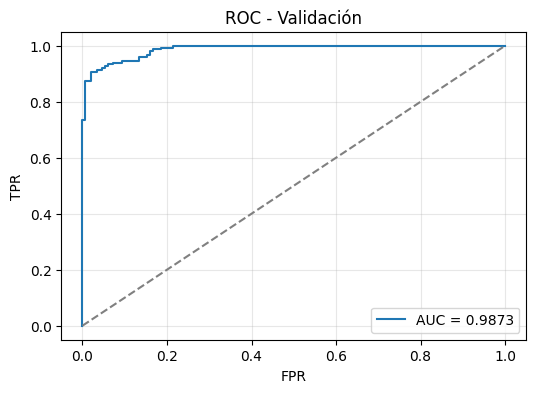

In [15]:
#ROC curve en validacion
fpr, tpr, _ = roc_curve(y_val, y_val_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {val_metrics["roc_auc"]:.4f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC - Validación')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [16]:
#training con train+val y evaluar test
final_model = grid.best_estimator_
final_model.fit(X_train_val, y_train_val)

test_metrics, y_test_pred, y_test_prob = compute_metrics(final_model, X_test, y_test)
display(pd.DataFrame([test_metrics]).style.format('{:.4f}'))
print(classification_report(y_test, y_test_pred, target_names=['ham', 'spam']))
print('Confusion matrix (test):')
print(confusion_matrix(y_test, y_test_pred))

,accuracy,precision,recall,f1,roc_auc,binary_crossentropy
0,0.9500,0.9295,0.9732,0.9508,0.9876,0.1493


              precision    recall  f1-score   support

         ham       0.97      0.93      0.95       151
        spam       0.93      0.97      0.95       149

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300

Confusion matrix (test):
[[140  11]
 [  4 145]]


## Resumen

- Algoritmo utilizado: **Naive Bayes** (`MultinomialNB`).
- Embeddings evaluados: **Bag-of-Words** y **TF-IDF**.
- Se utiliza validación cruzada para seleccionar hiperparámetros en entrenamiento.
- Se reportan métricas en validación y prueba: Accuracy, Precision, Recall, F1, ROC AUC y Binary Crossentropy.